# Cavity Optomechanics

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Introduction: 
Hamiltonian un the rotating frames at laser frecuency
$$H_{sys}= -\hbar \Delta_0 aa^\dagger + \hbar \omega_m bb^\dagger - \hbar g_0(b^\dagger+b) a^\dagger a + i\hbar A_l(a^\dagger- a)$$



Quantum Langevin equaitons
$$\dot{a} = -(\kappa/2 - i\Delta_0)a + ig_0(b+b^\dagger)a + A_j + \sqrt{\kappa} a_{in}$$

$$\dot{b} = -(\gamma/2 + i\omega_0)b + ig_0aa^\dagger + \sqrt{\gamma} a_{in}$$


## Classical regime
$$\dot{\alpha} = -(\kappa/2 - i\Delta)\alpha + A_j \quad where \quad \Delta = \Delta_0 + g_0(\beta^*+ \beta)  $$

$$\dot{\beta} = -(\gamma/2 + i\omega_0)\beta + ig_0\alpha\alpha^*$$





### Mean optical occupacy at steady state at classical regime
$$4C^2N_0^3+8C\Delta_0N_0^2+(4\Delta_0^2+\kappa^2)N_0-4|A_l|^2=0$$


In [9]:
def f(x,Delta_0,g_0,A_l,gamma,kappa):
    C = 2*g_0**2/(gamma**2/4+1)
    return 4*C**2*x**3 + 8*C*Delta_0*x**2 + (4*Delta_0**2 + kappa**2)*x - 4*A_l**2    
def mean_octical_occupacy(Delta_0,g_0,A_l,gamma,kappa,interval):
    x = np.linspace(interval[0],interval[1],10000)
    y = f(x,Delta_0,g_0,A_l,gamma,kappa)
    #y = np.array([f(xi,Delta_0,g_0,A_l,gamma,kappa) for xi in x])
    zeros = []
    for i in range(len(x)-1):
        if y[i]*y[i+1] <= 0:
           zeros.append(x[i]) 
    return zeros
 
Delta_0 = np.linspace(-0.5,0.5,1000) 
g_0     = [0.000,0.002,0.004,0.006]
A_l     = 5.0
gamma   = 0.005
kappa   = 0.15

points = []
for i in range(len(g_0)):
    points_g0_fixed = [] 
    for Delta_0i in Delta_0:
        occupacy = mean_octical_occupacy(Delta_0i,g_0[i],A_l,gamma,kappa,[0,5*10**3])
        points_g0_fixed.extend([[Delta_0i,occupacyi] for  occupacyi in  occupacy])
    points_g0_fixed = np.array(points_g0_fixed)
    points.append(points_g0_fixed)


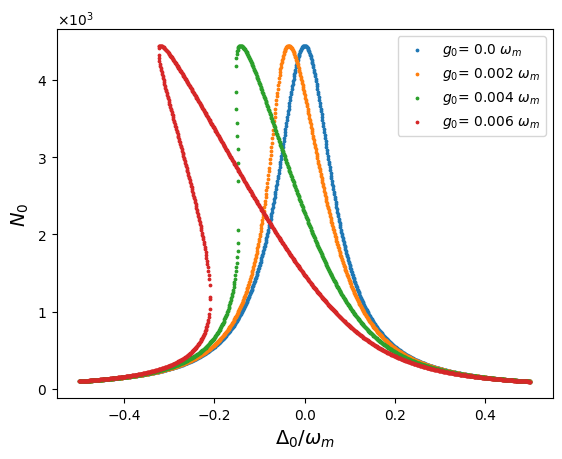

In [10]:
labels =  [rf'$g_0$= {g_0i} $\omega_m$' for g_0i in g_0]
fig, ax = plt.subplots()
#ax.plot(x, y)
for i in range(len(g_0)):
    ax.scatter(points[i][:,0],points[i][:,1],s=3, label=labels[i])
plt.legend()
plt.ylabel(r"$N_0$",fontsize=14)
plt.xlabel(r"$\Delta_0/\omega_m$",fontsize=14)

ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)




### Optomechanical Damping

In [19]:
kappas = [0.25,0.5,1,2] ## In units omega_m
Deltas  = np.linspace(-2,2,1000)  ## In units omega_m
gamma_om = [ [kappa*(1/(kappa**2/4+(1+Delta)**2)-1/(kappa**2/4+(1-Delta)**2)) for Delta in Deltas] for kappa in kappas] 
gamma_om = np.array(gamma_om)


Text(0, 0.5, '$\\gamma_{om}\\omega_m/g^2_s$')

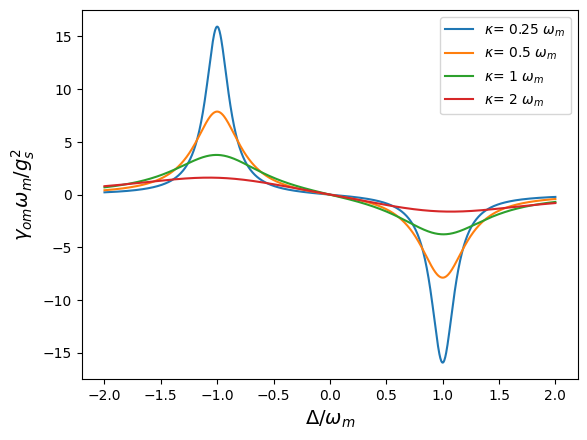

In [21]:
labels =  [rf'$\kappa$= {kappai} $\omega_m$' for kappai in kappas]
fig, ax = plt.subplots()

for i in range(len(kappas)):
    ax.plot(Deltas,gamma_om[i],label=labels[i])
plt.legend()
plt.xlabel(r"$\Delta/\omega_m$",fontsize=14)
plt.ylabel(r"$\gamma_{om}\omega_m/g^2_s$",fontsize=14)
    
    

In [26]:
delta_omega_m = [ [((1+Delta)/(kappa**2/4+(1+Delta)**2)-(1-Delta)/(kappa**2/4+(1-Delta)**2)) for Delta in Deltas] for kappa in kappas] 
delta_omega_m = np.array(delta_omega_m)

Text(0, 0.5, '$\\delta\\omega_m\\omega_m/g^2_s$')

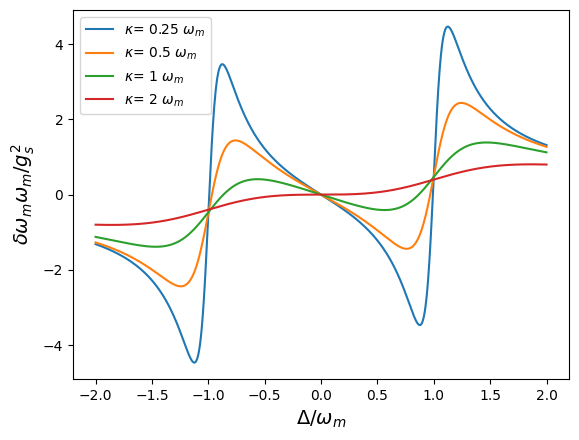

In [29]:
labels =  [rf'$\kappa$= {kappai} $\omega_m$' for kappai in kappas]
fig, ax = plt.subplots()

for i in range(len(kappas)):
    ax.plot(Deltas,delta_omega_m[i],label=labels[i])
plt.legend()
plt.xlabel(r"$\Delta/\omega_m$",fontsize=14)
plt.ylabel(r"$\delta\omega_m\omega_m/g^2_s$",fontsize=14)